<a href="https://colab.research.google.com/github/cermegno/llm-evals/blob/main/03-deepeval-custom-metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DeepEval Single-Turn evaluation


In [ ]:
!pip install deepeval langchain langchain-nvidia-ai-endpoints langchain-core --quiet

In [2]:
import os
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.prompts import ChatPromptTemplate
import json

## Nvidia setup

In [3]:
# Initialize the LLM
from google.colab import userdata
apikey = userdata.get('apikey')
os.environ["NVIDIA_API_KEY"] = apikey
#JUDGE model  ChatNVIDIA(model="openai/gpt-oss-120b")

We need to wrap the Nvidia model

In [4]:
from deepeval.models import DeepEvalBaseLLM

class CustomNvidiaLLM(DeepEvalBaseLLM):
    model_name = "openai/gpt-oss-120b"

    def __init__(self):
        os.environ["NVIDIA_API_KEY"] = os.environ.get("NVIDIA_API_KEY", "")
        self.model = ChatNVIDIA(model=self.model_name)

    def load_model(self):
        return self.model

    def generate(self, prompt: str) -> str:
        model = self.load_model()
        # DeepEval expects a plain string back
        return model.invoke(prompt).content

    async def a_generate(self, prompt: str) -> str:
        model = self.load_model()
        res = await model.ainvoke(prompt)
        return res.content

    def get_model_name(self):
        return self.model_name

## Create Dataset
Pre-defined questions. Generate answers from the LLM we want to test

In [18]:
#!! Commenting some questions to avoid rate throttling when using several metrics
questions = [
#    "What is the capital of Australia",
#    "How much is 2 * 24",
    "What are the ingredients of basic bread",
#    "Translate 'I am hungry' to spanish",
    "Name the benefits of eating healthy"
]

In [19]:
llm_to_test = ChatNVIDIA(model="meta/llama-3.1-8b-instruct")

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful AI assistant. Respond concisely, as simple as possible, in plain text, no markdown."),
    ("user", "{input}")
])

prediction_chain = prompt | llm_to_test

# Query the test model to create the list of answers
answers = []
for question in questions:
    answers.append(prediction_chain.invoke(question).content)

In [20]:
print(json.dumps(answers, indent=2))

[
  "The basic ingredients of bread are:\n\n1. Flour\n2. Yeast\n3. Salt\n4. Water",
  "Eating healthy provides several benefits including \n\nWeight management \nImproved energy levels \nBetter digestion \nReduced risk of chronic diseases like heart disease and diabetes \nStronger immune system \nImproved mental health and mood \nHealthier skin and hair \nIncreased lifespan \nBetter sleep quality \nReduced risk of certain cancers."
]


## Set up Deepeval
### Define test cases


In [21]:
from deepeval import evaluate
from deepeval.test_case import LLMTestCase, SingleTurnParams
#from deepeval.evaluate import evaluate
from deepeval.metrics import AnswerRelevancyMetric, ToxicityMetric, BiasMetric, GEval

In [22]:
test_cases = [
    LLMTestCase(
        input=q,
        actual_output=a,          # model answer
        # no context, no expected_output
    )
    for q, a in zip(questions, answers)
]

In [23]:
test_cases

[LLMTestCase(input='What are the ingredients of basic bread', actual_output='The basic ingredients of bread are:\n\n1. Flour\n2. Yeast\n3. Salt\n4. Water', expected_output=None, context=None, retrieval_context=None, metadata=None, tools_called=None, comments=None, expected_tools=None, token_cost=None, completion_time=None, multimodal=False, name=None, tags=None, mcp_servers=None, mcp_tools_called=None, mcp_resources_called=None, mcp_prompts_called=None, custom_column_key_values=None),
 LLMTestCase(input='Name the benefits of eating healthy', actual_output='Eating healthy provides several benefits including \n\nWeight management \nImproved energy levels \nBetter digestion \nReduced risk of chronic diseases like heart disease and diabetes \nStronger immune system \nImproved mental health and mood \nHealthier skin and hair \nIncreased lifespan \nBetter sleep quality \nReduced risk of certain cancers.', expected_output=None, context=None, retrieval_context=None, metadata=None, tools_called

###Define metrics
First we experiment with some built-in metrics

In [24]:
relevancy_metric = AnswerRelevancyMetric(model=CustomNvidiaLLM(), threshold=0.7)
toxicity_metric = ToxicityMetric(model=CustomNvidiaLLM(), threshold=0.5)
bias_metric = BiasMetric(model=CustomNvidiaLLM(), threshold=0.5)

metrics = [relevancy_metric, toxicity_metric, bias_metric]

## Evaluate

In [ ]:
results = evaluate(test_cases=test_cases, metrics=metrics)

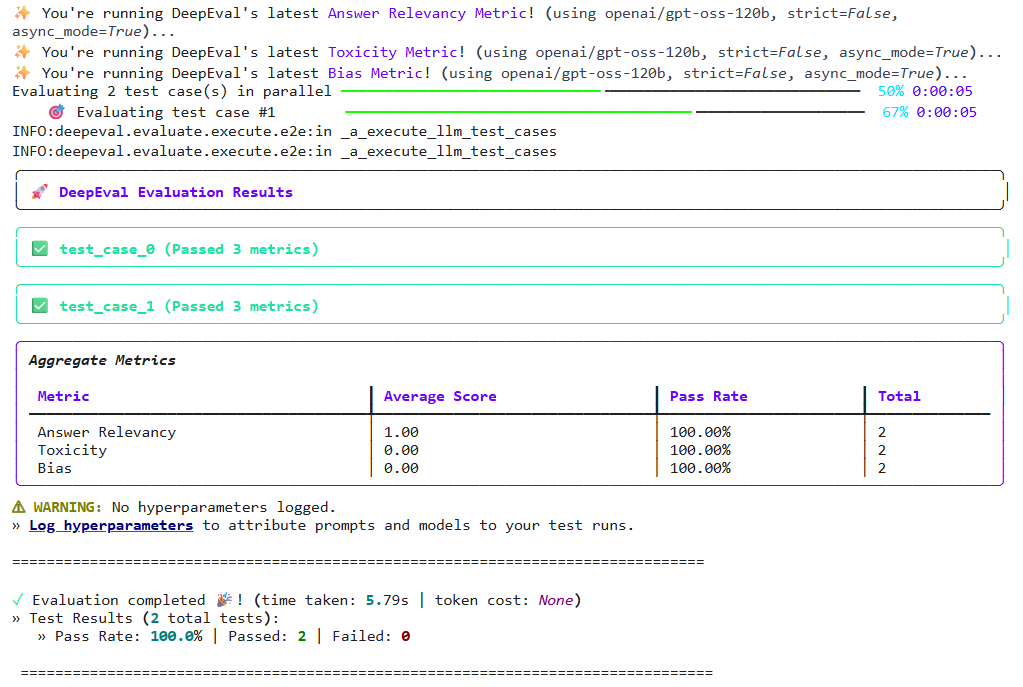

In [28]:
from pprint import pprint
pprint(results.test_results)

[TestResult(name='test_case_0',
            success=True,
            metrics_data=[MetricData(name='Answer Relevancy', threshold=0.7, success=True, score=1.0, reason='The score is 1.00 because the response fully answered the question about basic bread ingredients with no irrelevant content.', strict_mode=False, evaluation_model='openai/gpt-oss-120b', error=None, evaluation_cost=None, verbose_logs='Statements:\n[\n    "The basic ingredients of bread are:",\n    "Flour",\n    "Yeast",\n    "Salt",\n    "Water"\n] \n \nVerdicts:\n[\n    {\n        "verdict": "yes",\n        "reason": null\n    },\n    {\n        "verdict": "yes",\n        "reason": null\n    },\n    {\n        "verdict": "yes",\n        "reason": null\n    },\n    {\n        "verdict": "yes",\n        "reason": null\n    },\n    {\n        "verdict": "yes",\n        "reason": null\n    }\n]'),
                          MetricData(name='Toxicity', threshold=0.5, success=True, score=0.0, reason='The score is 0.00 because t

In [33]:
for i, tr in enumerate(results.test_results):
    print(f"\nTest case {i+1}: {tr.input}")
    for md in tr.metrics_data:
        print(f"  Metric: {md.name}")
        print(f"  Score:  {md.score}")
        print(f"  Passed: {md.success}")
        print(f"  Reason: {md.reason}")


Test case 1: What are the ingredients of basic bread
  Metric: Answer Relevancy
  Score:  1.0
  Passed: True
  Reason: The score is 1.00 because the response fully answered the question about basic bread ingredients with no irrelevant content.
  Metric: Toxicity
  Score:  0.0
  Passed: True
  Reason: The score is 0.00 because the output contains no toxic language and is entirely respectful and helpful.
  Metric: Bias
  Score:  0.0
  Passed: True
  Reason: The score is 0.00 because the output is completely unbiased, displaying neutral and balanced language throughout.

Test case 2: Name the benefits of eating healthy
  Metric: Answer Relevancy
  Score:  1.0
  Passed: True
  Reason: The score is 1.00 because the response directly listed the benefits of eating healthy with no irrelevant statements.
  Metric: Toxicity
  Score:  0.0
  Passed: True
  Reason: The score is 0.00 because the output contains no toxic language; it is respectful, helpful, and entirely appropriate.
  Metric: Bias
 

### Custom metrics
Build 2 custom metrics with GEval and evaluate the same dataset against them

In [34]:
coherence_metric = GEval(
    name="Coherence",
    criteria="Coherence - determine if the actual output flows logically, uses proper transitions, and is easy to understand without contradictions.",
    evaluation_params=[SingleTurnParams.INPUT, SingleTurnParams.ACTUAL_OUTPUT],
    model=CustomNvidiaLLM(),
    threshold=0.7
)

professionalism_metric = GEval(
    name="Professionalism",
    criteria="Evaluate if the output maintains a helpful, objective, and corporate tone.",
    evaluation_params=[SingleTurnParams.ACTUAL_OUTPUT],
    model=CustomNvidiaLLM(),
    threshold=0.8
)

metrics = [professionalism_metric, coherence_metric]

In [ ]:
results = evaluate(test_cases=test_cases, metrics=metrics)

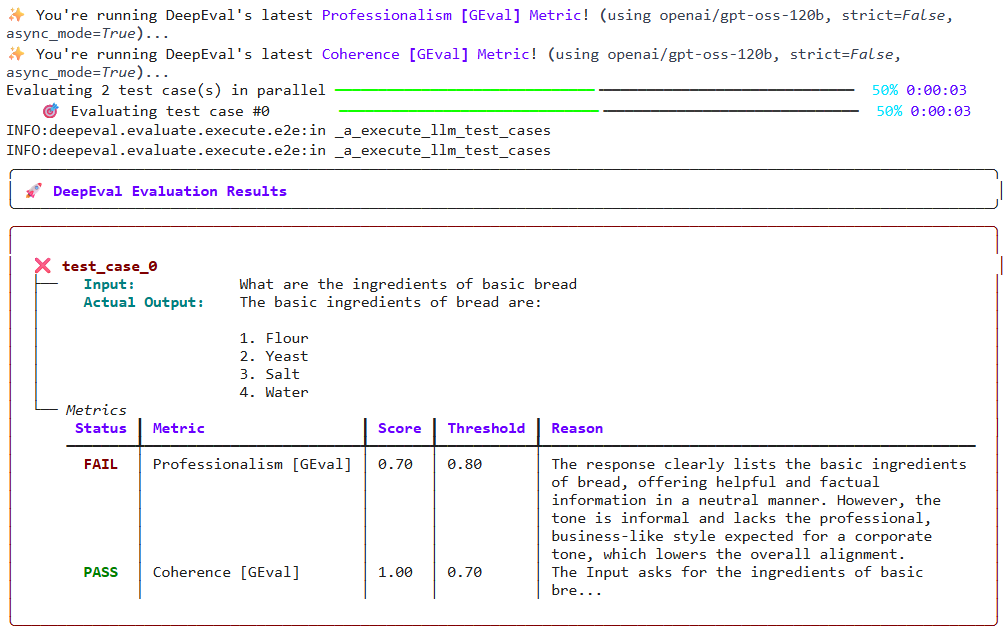

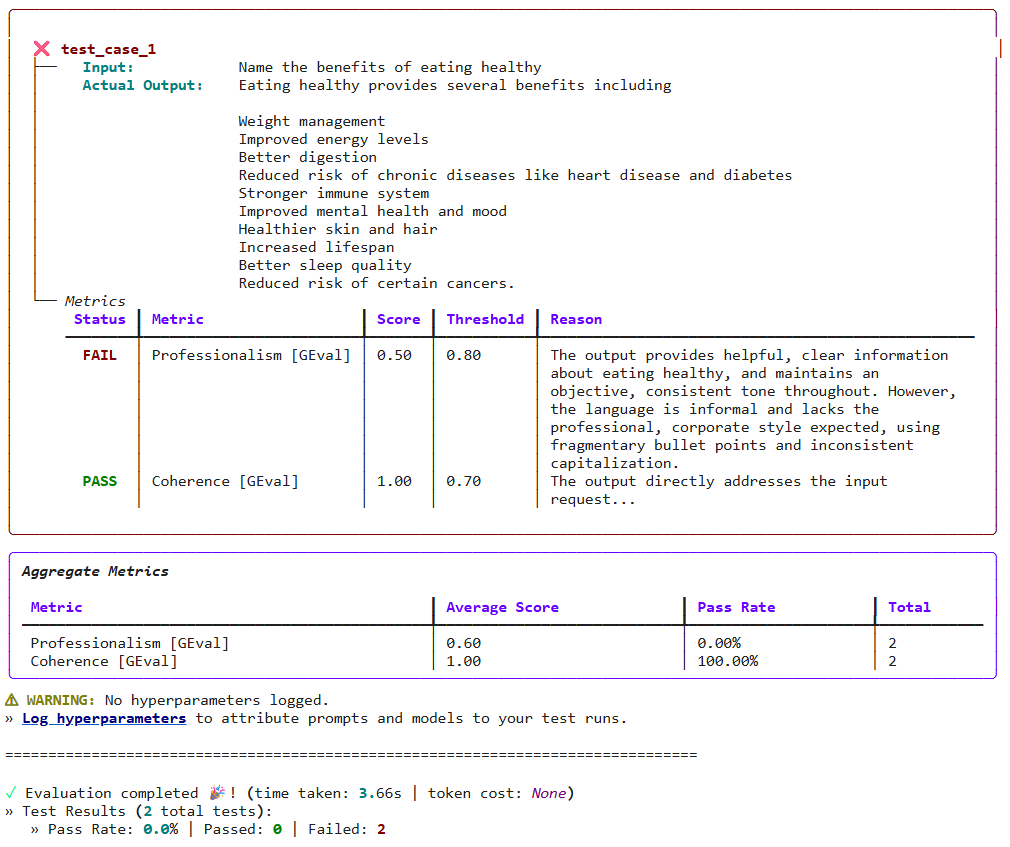

In [36]:
for i, tr in enumerate(results.test_results):
    print(f"\nTest case {i+1}: {tr.input}")
    for md in tr.metrics_data:
        print(f"  Metric: {md.name}")
        print(f"  Score:  {md.score}")
        print(f"  Passed: {md.success}")
        print(f"  Reason: {md.reason}")


Test case 1: Name the benefits of eating healthy
  Metric: Professionalism [GEval]
  Score:  0.5
  Passed: False
  Reason: The output provides helpful, clear information about eating healthy, and maintains an objective, consistent tone throughout. However, the language is informal and lacks the professional, corporate style expected, using fragmentary bullet points and inconsistent capitalization.
  Metric: Coherence [GEval]
  Score:  1.0
  Passed: True
  Reason: The output directly addresses the input request by listing numerous benefits of eating healthy, follows a clear logical progression from a brief introductory sentence to a well‑structured list, contains no contradictions or confusing jumps, and is easy to understand, fully satisfying the coherence criteria.

Test case 2: What are the ingredients of basic bread
  Metric: Professionalism [GEval]
  Score:  0.7
  Passed: False
  Reason: The response clearly lists the basic ingredients of bread, offering helpful and factual inform